# BTPR3203 Python for Data Science - Case Study
## Topic: Analysis of Industrial and Domestic Water Consumption Patterns in Malaysia (2003–2022)

### Research Questions (SMART Criteria)
1. **Q1 (Data Preparation & Feature Engineering)**: How can we clean the nationwide water dataset by filtering out national aggregates (`Malaysia`) and engineer a new feature (`nondomestic_share`) to measure regional industrial/commercial water demand intensity?
2. **Q2 (Data Analysis)**: What are the compound annual growth rates (CAGR) and overall consumption trends of non-domestic water across major industrial hubs (Selangor, Johor, Penang) from 2003 to 2022?
3. **Q3 (Visualisation)**: How does the spatial distribution and consumption tiering of non-domestic water share vary across Malaysian states as of 2022?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv('water_consumption.csv')

# 2. Inspect basic structure and column data types
print("=== Dataset Overview ===")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Column Info ---")
print(df.info())

print("\n--- First 5 Rows ---")
print(df.head())

# 3. Check for missing values and duplicates
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows Check ---")
print(f"Total duplicates: {df.duplicated().sum()}")

# 4. Check unique categories
print("\n--- Unique States ---")
print(df['state'].unique())

print("\n--- Unique Sectors ---")
print(df['sector'].unique())
# 5. Basic descriptive statistics of the raw 'value' column (required by 3.2)
print("\n--- Basic Descriptive Statistics (raw 'value' column, Million Litres) ---")
print(df['value'].describe())

# 6. Explicit missing value / duplicate handling decision
if df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0:
    print("\nNo missing values or duplicate rows were found. No imputation or "
          "row-dropping was necessary; the raw dataset was used as-is for the "
          "cleaning steps below.")
else:
    print("\nMissing values or duplicates were detected and must be handled "
          "before proceeding (see strategy in the markdown cell below).")

=== Dataset Overview ===
Dataset Shape: 600 rows, 4 columns

--- Column Info ---
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   state   600 non-null    str  
 1   sector  600 non-null    str  
 2   date    600 non-null    str  
 3   value   600 non-null    int64
dtypes: int64(1), str(3)
memory usage: 18.9 KB
None

--- First 5 Rows ---
      state    sector        date  value
0  Malaysia  domestic  2003-01-01   4394
1  Malaysia  domestic  2004-01-01   4770
2  Malaysia  domestic  2005-01-01   4992
3  Malaysia  domestic  2006-01-01   5025
4  Malaysia  domestic  2007-01-01   5381

--- Missing Values Check ---
state     0
sector    0
date      0
value     0
dtype: int64

--- Duplicate Rows Check ---
Total duplicates: 0

--- Unique States ---
<StringArray>
[       'Malaysia',           'Johor',           'Kedah',        'Kelantan',
          'Melaka', 'Negeri Sembilan',   

### 3.2 Data Cleaning and Feature Engineering Strategy

1. **Filtering Aggregates**: The dataset contains a row entry where `state == 'Malaysia'`, which represents the national sum. To avoid double-counting during state-level comparisons, we filter out national aggregates.
2. **Pivot Transformation**: The original dataset stores `sector` (`domestic` vs `nondomestic`) as categorical rows. We pivot these into separate columns to compare sector consumption directly per state and year.
3. **Feature Engineering**:
   - `total`: Total water consumption (`domestic` + `nondomestic`).
   - `nondomestic_share`: Percentage of water consumed by non-domestic (industrial/commercial) sectors relative to total consumption ($\frac{\text{nondomestic}}{\text{total}} \times 100\%$).
4. **Missing Values & Duplicates**: `df.isnull().sum()` and `df.duplicated().sum()` were both checked (see output above) and returned zero in every column. Since DOSM/SPAN publish this series as a finalised annual statistic, no imputation, interpolation, or row-dropping was required — the dataset was used in its original form.
5. **Assumptions & Alternatives Considered**: We assume each state-year-sector combination is a single authoritative reading (not a sample requiring de-duplication). An alternative would have been to keep `sector` in long format and use `groupby` at analysis time instead of pivoting; we chose to pivot early because it makes the `nondomestic_share` feature possible to compute once and reuse across all three analytical operations, rather than recomputing it repeatedly.

In [3]:
# 1. Filter out national aggregate 'Malaysia'
df_states = df[df['state'] != 'Malaysia'].copy()

# 2. Extract year from date
df_states['year'] = pd.to_datetime(df_states['date']).dt.year

# 3. Pivot sector values into columns
df_pivot = df_states.pivot_table(
    index=['state', 'year'], 
    columns='sector', 
    values='value'
).reset_index()

# 4. Feature Engineering: Calculate Total Water Consumption and Non-Domestic Share (%)
df_pivot['total'] = df_pivot['domestic'] + df_pivot['nondomestic']
df_pivot['nondomestic_share'] = (df_pivot['nondomestic'] / df_pivot['total']) * 100

# 5. Display clean transformed DataFrame
print("=== Transformed Dataset Overview ===")
print(f"Shape: {df_pivot.shape[0]} rows, {df_pivot.shape[1]} columns")
print("\n--- First 5 Rows of Cleaned Data ---")
print(df_pivot.head())

print("\n--- Summary Statistics of Non-Domestic Share (%) by State ---")
print(df_pivot.groupby('state')['nondomestic_share'].describe()[['mean', 'min', 'max']])

=== Transformed Dataset Overview ===
Shape: 280 rows, 6 columns

--- First 5 Rows of Cleaned Data ---
sector  state  year  domestic  nondomestic  total  nondomestic_share
0       Johor  2003     560.0        246.0  806.0          30.521092
1       Johor  2004     610.0        225.0  835.0          26.946108
2       Johor  2005     621.0        235.0  856.0          27.453271
3       Johor  2006     644.0        255.0  899.0          28.364850
4       Johor  2007     664.0        289.0  953.0          30.325289

--- Summary Statistics of Non-Domestic Share (%) by State ---
                      mean        min        max
state                                           
Johor            33.445669  26.946108  41.771269
Kedah            26.248667  22.709163  32.420091
Kelantan         30.656694  27.131783  34.274194
Melaka           45.934893  32.179931  50.471698
Negeri Sembilan  40.728540  27.358491  45.588235
Pahang           38.548686  25.242718  45.933014
Perak            27.501408  2

### 3.3 Data Analysis & Statistical Findings

We conduct three distinct analytical operations to address our research questions:

1. **Analytical Operation 1 (CAGR for Key Industrial Hubs)**: Calculates the Compound Annual Growth Rate (CAGR) of non-domestic water consumption from 2003 to 2022 for Selangor, Johor, and Pulau Pinang using the formula:
   $$\text{CAGR} = \left( \frac{\text{Value}_{2022}}{\text{Value}_{2003}} \right)^{\frac{1}{19}} - 1$$

2. **Analytical Operation 2 (Nationwide Trend Aggregation)**: Aggregates total domestic and non-domestic water consumption across all 14 states/territories year-by-year to assess long-term structural demand shifts.

3. **Analytical Operation 3 (2022 State Industrial Intensity Ranking)**: Ranks states based on their 2022 `nondomestic_share` (%) to evaluate regional variations in industrial water demand.
**Alternatives Considered**: A simple year-on-year percentage change or an OLS linear trend were both considered for Operation 1. CAGR was chosen instead because it smooths out single-year volatility (e.g., the 2020–2021 COVID-related dip visible in Figure 1) into one comparable annualised rate, which is more appropriate for a 20-year comparison across three states than a trend line sensitive to endpoint noise.

In [3]:
# ==============================================================================
# Analytical Operation 1: CAGR Calculation for Major Industrial Hubs (2003-2022)
# ==============================================================================
hubs = ['Selangor', 'Johor', 'Pulau Pinang']
cagr_list = []

for state in hubs:
    v2003 = df_pivot[(df_pivot['state'] == state) & (df_pivot['year'] == 2003)]['nondomestic'].values[0]
    v2022 = df_pivot[(df_pivot['state'] == state) & (df_pivot['year'] == 2022)]['nondomestic'].values[0]
    cagr = (((v2022 / v2003) ** (1 / 19)) - 1) * 100
    cagr_list.append({
        'State': state,
        '2003 Non-Domestic (Mil Litres)': v2003,
        '2022 Non-Domestic (Mil Litres)': v2022,
        'CAGR (%)': round(cagr, 2)
    })

df_cagr = pd.DataFrame(cagr_list)
print("=== Analytical Operation 1: CAGR of Non-Domestic Water Consumption (2003–2022) ===")
print(df_cagr.to_string(index=False))

# ==============================================================================
# Analytical Operation 2: Nationwide Sector Aggregation (2003 vs 2022)
# ==============================================================================
yearly_agg = df_pivot.groupby('year')[['domestic', 'nondomestic', 'total']].sum().reset_index()
yearly_agg['nondomestic_share'] = (yearly_agg['nondomestic'] / yearly_agg['total']) * 100

v2003_total_nd = yearly_agg.loc[yearly_agg['year'] == 2003, 'nondomestic'].values[0]
v2022_total_nd = yearly_agg.loc[yearly_agg['year'] == 2022, 'nondomestic'].values[0]
national_nd_cagr = (((v2022_total_nd / v2003_total_nd) ** (1 / 19)) - 1) * 100

print("\n=== Analytical Operation 2: Nationwide Aggregated Shift ===")
print(f"2003 Total Non-Domestic Water Consumption: {v2003_total_nd} Mil Litres")
print(f"2022 Total Non-Domestic Water Consumption: {v2022_total_nd} Mil Litres")
print(f"Nationwide Non-Domestic Consumption CAGR: {national_nd_cagr:.2f}%")

# ==============================================================================
# Analytical Operation 3: 2022 State Ranking by Non-Domestic Water Share (%)
# ==============================================================================
df_2022_rank = df_pivot[df_pivot['year'] == 2022].sort_values(by='nondomestic_share', ascending=False)

print("\n=== Analytical Operation 3: 2022 State Ranking by Non-Domestic Share (%) ===")
print(df_2022_rank[['state', 'domestic', 'nondomestic', 'total', 'nondomestic_share']].to_string(index=False))

=== Analytical Operation 1: CAGR of Non-Domestic Water Consumption (2003–2022) ===
       State  2003 Non-Domestic (Mil Litres)  2022 Non-Domestic (Mil Litres)  CAGR (%)
    Selangor                           673.0                          1350.0      3.73
       Johor                           246.0                           536.0      4.18
Pulau Pinang                           235.0                           334.0      1.87

=== Analytical Operation 2: Nationwide Aggregated Shift ===
2003 Total Non-Domestic Water Consumption: 2281.0 Mil Litres
2022 Total Non-Domestic Water Consumption: 4432.0 Mil Litres
Nationwide Non-Domestic Consumption CAGR: 3.56%

=== Analytical Operation 3: 2022 State Ranking by Non-Domestic Share (%) ===
          state  domestic  nondomestic  total  nondomestic_share
    W.P. Labuan      19.0         33.0   52.0          63.461538
         Melaka     228.0        190.0  418.0          45.454545
        Sarawak     602.0        463.0 1065.0          43.474178


### 3.4 Meaningful Data Visualisations

To communicate our analytical findings effectively, we generate three visualisations:

- **Figure 1**: A line chart illustrating the 20-year growth trajectories of non-domestic water demand across Malaysia's primary industrial powerhouses (Selangor, Johor, and Pulau Pinang).
- **Figure 2**: A stacked bar chart presenting the structural composition of nationwide annual water usage from 2003 to 2022.
- **Figure 3**: A ranked horizontal bar chart depicting the 2022 industrial water intensity (`nondomestic_share`) across all 14 states and federal territories.

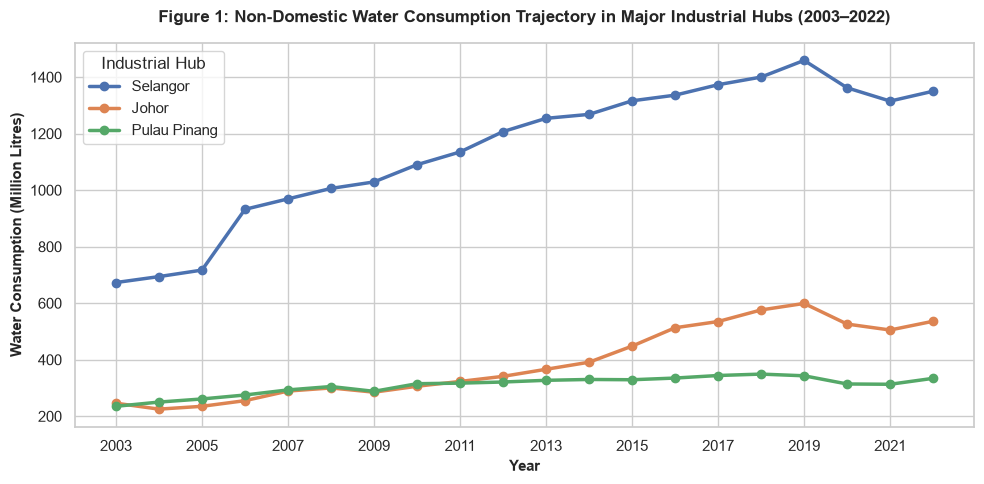

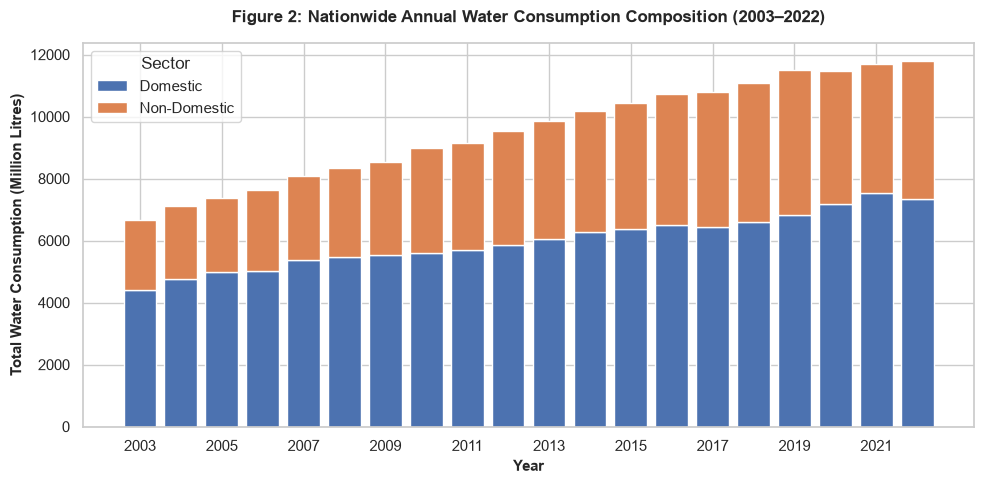

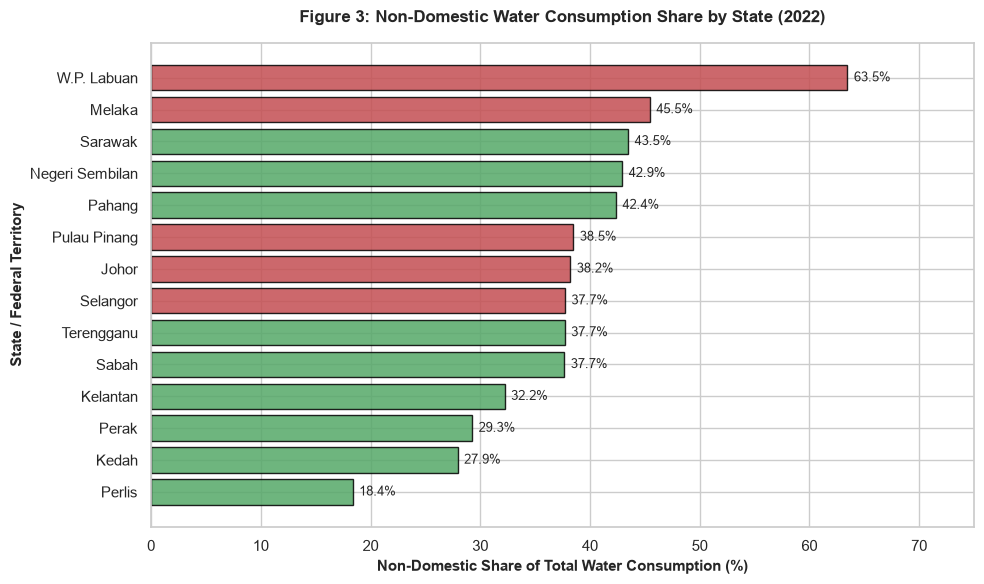

Charts successfully saved to 'charts/' folder.


In [4]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create directory to store output image files for submission
os.makedirs('charts', exist_ok=True)
sns.set_theme(style="whitegrid")

# ==============================================================================
# Figure 1: Line Chart for Major Industrial Hubs (2003–2022)
# ==============================================================================
plt.figure(figsize=(10, 5))
hubs = ['Selangor', 'Johor', 'Pulau Pinang']

for state in hubs:
    subset = df_pivot[df_pivot['state'] == state]
    plt.plot(subset['year'], subset['nondomestic'], marker='o', linewidth=2.5, label=state)

plt.title('Figure 1: Non-Domestic Water Consumption Trajectory in Major Industrial Hubs (2003–2022)', 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=11, fontweight='bold')
plt.ylabel('Water Consumption (Million Litres)', fontsize=11, fontweight='bold')
plt.xticks(range(2003, 2023, 2))
plt.legend(title='Industrial Hub', frameon=True)
plt.tight_layout()
plt.savefig('charts/fig1_industrial_hubs_trend.png', dpi=300)
plt.show()

# ==============================================================================
# Figure 2: Stacked Bar Chart for National Water Composition (2003–2022)
# ==============================================================================
plt.figure(figsize=(10, 5))
yearly_agg = df_pivot.groupby('year')[['domestic', 'nondomestic']].sum().reset_index()

plt.bar(yearly_agg['year'], yearly_agg['domestic'], label='Domestic', color='#4C72B0')
plt.bar(yearly_agg['year'], yearly_agg['nondomestic'], bottom=yearly_agg['domestic'], label='Non-Domestic', color='#DD8452')

plt.title('Figure 2: Nationwide Annual Water Consumption Composition (2003–2022)', 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=11, fontweight='bold')
plt.ylabel('Total Water Consumption (Million Litres)', fontsize=11, fontweight='bold')
plt.xticks(range(2003, 2023, 2))
plt.legend(title='Sector', frameon=True)
plt.tight_layout()
plt.savefig('charts/fig2_national_sector_composition.png', dpi=300)
plt.show()

# ==============================================================================
# Figure 3: Horizontal Bar Chart for 2022 State Industrial Water Share (%)
# ==============================================================================
plt.figure(figsize=(10, 6))
df_2022_sorted = df_pivot[df_pivot['year'] == 2022].sort_values(by='nondomestic_share', ascending=True)

# Highlight key industrial hubs in contrast color
highlight_states = ['Selangor', 'Johor', 'Pulau Pinang', 'Melaka', 'W.P. Labuan']
colors = ['#C44E52' if state in highlight_states else '#55A868' for state in df_2022_sorted['state']]

bars = plt.barh(df_2022_sorted['state'], df_2022_sorted['nondomestic_share'], color=colors, edgecolor='black', alpha=0.85)

# Annotate values on bar tips
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.6, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', ha='left', va='center', fontsize=9)

plt.title('Figure 3: Non-Domestic Water Consumption Share by State (2022)', 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Non-Domestic Share of Total Water Consumption (%)', fontsize=11, fontweight='bold')
plt.ylabel('State / Federal Territory', fontsize=11, fontweight='bold')
plt.xlim(0, 75)
plt.tight_layout()
plt.savefig('charts/fig3_2022_state_share_ranking.png', dpi=300)
plt.show()

print("Charts successfully saved to 'charts/' folder.")

# BTPR3203 Case Study: Sustainable Manufacturing & Water Consumption Patterns in Malaysia

## Overview
This repository contains the Python data science analysis for the **BTPR3203 Python for Data Science Case Study (Semester B, 2026)** at Southern University College.

The study investigates long-term industrial and domestic water usage patterns across Malaysian states (2003–2022) as a proxy indicator for sustainable manufacturing and regional industrial growth.

## Research Questions (SMART)
- **Q1 (Data Preparation)**: Clean nationwide water consumption data by filtering national aggregates (`Malaysia`) and engineer a derived metric (`nondomestic_share`) to measure regional industrial/commercial water demand intensity.
- **Q2 (Data Analysis)**: Evaluate the Compound Annual Growth Rates (CAGR) and total consumption trajectories of non-domestic water across primary industrial hubs (Selangor, Johor, Penang) versus national trends from 2003 to 2022.
- **Q3 (Visualisation)**: Analyze the spatial distribution and tiering of non-domestic water share across all Malaysian states as of 2022.

## Repository Structure
- `analysis.ipynb`: Fully executed Jupyter Notebook containing data loading, cleaning, feature engineering, statistical analysis, and visualizations.
- `water_consumption.csv`: Primary dataset sourced from DOSM / SPAN via `data.gov.my`.
- `charts/`: Exported high-resolution (300 DPI) chart images (`fig1`, `fig2`, `fig3`).

## Key Dependencies
- `pandas`
- `numpy`
- `matplotlib`
- `seaborn`